##### The Pioneer
LeNet-5
Before LeNet, computer vision relied on hand-crafted features, this involved researchers and engineers spending several hours, days or even months manually designing image features based on domain knowledte and intuition about what visual patterns migh be important for specific tasks (i suspect you probably had to be very smart for this). so what are some of these features?
- edge detection: using mathematical formulas to manually identify edges in an image by computing the gradient change from the veritical to horizontal direction
- texture descriptors: identifying certain textures within an image
- corner and interest point detection
- template matching and correlation
- fourier and frequency domain features

etc etc (very mathy)
This was very time consuming, did not generalize and was not scalable due to the amount of manual effort required. One day in ~1998, a young frenchman thought to himself, "i'm going to unhappy if i spend the rest of my life writing down equations for the computer to detect images, why am i working for the computer? the computer should work for me!" and then he started thinking, how can i get the computer to learn these features by itself, and then use the learned features to do the intended task, the name of this young frenchman....Yann LeCunn. The challenge was to learn the visual patterns <u>directly</u> from raw pixel data. His challenge? document recognition! Now, given how good chatgeeppeeteeee and the rest are at document recognition, you might be thinking that must be trivial, but back in the late 90s, that was seen as a miracle. At the time Yann was exploring the use of neural networks, a `gradient-based` way of learning from high dimensional patterns, particularly he was interested in `Convolutional Neural Networks` which are particullarly designed for the variability of 2d shapes. Yann was trying to make it more efficient to read checks (for those as young as me, a check is a paper that tells a bank i wanna give someone some money, kinda like a venmo/paypal/stripe transaction, except that it was on paper, and someone phyically had to read it, understand it, decide if you are liar or not, then give you the money, must've been fun) both business and personnal checks. Since document understanding was a multi stage problem, he used convolutional neural networks as one of modules within a learning paradignm called `Graph Transformer Network` (lol, the foreshadowning) which had different jointly learnt modules for field extraction, segmentation, recognition and language modelling. Why didn't anyone do this before? Well, people tried, it was just too computationally expensive and required too much data to try and work with neural networks on high dimensional data, lucky for Yann, the computers just got faster and data was there (this is a recurring trend in deep learning as we will see my fellow journey<man/woman/person>).


So let't talk about Convolutional Neural Networks, the core of Yann's idea was the use of this customized version of the general neural architecture that was particularly good at dealing with 2d data. Feedinging an image directly into a neural network would not be effective, as the dimenstions would be large, on a 10 x 10 image thats 100 features, on a 1024 by 1024 image that a 1,048,576 features, as the size of the image goes higher it becomes completly unrealistic to feed a neural network data inputs with such as a high dimension as learning would become difficult and unstable. Another issue with feeding the entire image directly into the neural network is that there would be no inbuilt variance or robustness for local distortion, what does this mean? Remember the problem Yann is trying to solve here is handwriting recognition, differnet people write very differently from the way the i's are dottend to teh way the c's are curved, there is no exact way that everyone writes, but in most cases if you see a character you can tell what it is. If the models were to learn from the pixels directly they need to be able to handle changes in rotation, fold, or other forms of distortion to the image, because in reality that is what would be exprienced when the system is deployed to banks for reading checks. To solve the invariance problem, Yann believed that we needed several smaller networks at various parts of the images identifying certain patterns and coming back togehr to share their results, then agreeing on whether a particular feature was identified or not. each of those small netowrks would have the same weights and are basically target hunters, going though the entire image looking for a particular shape, color, texture or pattern, and then aggregating the responses from all the various parts of the image to conclude if the target was found or not. Another challenge that Yann had to solve was very particular to images, images have structure, the raw values of the pixels may not mean much, but the structural context provides the relevant information, i.e what are the values of its negihboors and what is its positional relationship to said neighboors. Convolutional Networks tacklbe both problems by having local receptive fields (don't look at the image as a whole, also don't look at just teh pixel, rather look at a pixel and its neighboors) it also enabled shared weights/weights replication (spoiler alert, this was discarded and not used in future iterations of cnn). Yann's idea for receptive fields also came from studying cat eyes (i'm not a biologist i am definetly not elaborating further), the receptive fields would building low level patterns in earlier layers, such as lines and edges, and in later layers would use those line and edges to detect shapes and groups and in future layers detect objects and targets, the idea was that shallow layers learn simpler features which are then built upon by deeper layers. The various small networks that are positoned as a plane across the image for detecting features are together called a feature map. A single convolutional layer would have several feature maps, with each feature map tring to learn a particular thing about the image (based on the deptho the network this could be lines, colors etc)

In [1]:
# we would be using the pytorch library as our prefered deep learning library for the dl120 challenge
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

/home/kaarl/miniconda3/envs/lgm-py310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# we have to build a custom transformation
mnist_data_transformer = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

In [3]:
### setting up the fashion mnist dataset

train_dataset = datasets.FashionMNIST(root='dataset/fashion_mnist', train=True, download=True, transform=transforms.ToTensor())
test_dataset = datasets.FashionMNIST(root='dataset/fashion_mnist', train=False, download=True, transform=transforms.ToTensor())

train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=1000, shuffle=True)

train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [0.8, 0.2])

train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=1000, shuffle=True)

100%|██████████| 26421880/26421880 [00:05<00:00, 4531057.67it/s]


Extracting dataset/fashion_mnist/FashionMNIST/raw/train-images-idx3-ubyte.gz to dataset/fashion_mnist/FashionMNIST/raw



100%|██████████| 29515/29515 [00:00<00:00, 850636.85it/s]


Extracting dataset/fashion_mnist/FashionMNIST/raw/train-labels-idx1-ubyte.gz to dataset/fashion_mnist/FashionMNIST/raw



100%|██████████| 4422102/4422102 [00:01<00:00, 4283175.42it/s]


Extracting dataset/fashion_mnist/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to dataset/fashion_mnist/FashionMNIST/raw



100%|██████████| 5148/5148 [00:00<00:00, 16173990.26it/s]

Extracting dataset/fashion_mnist/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to dataset/fashion_mnist/FashionMNIST/raw



In [19]:
# ### setting up the datasets
# print("setting up the datasets")
# train_dataset = datasets.MNIST(root='dataset/mnist', train=True, download=True, transform=mnist_data_transformer)
# test_dataset = datasets.MNIST(root='dataset/mnist', train=False, download=True, transform=mnist_data_transformer)

# print("setting up the dataloaders")
# train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
# test_loader = DataLoader(dataset=test_dataset, batch_size=1000, shuffle=True)

# ### split training data into train and validation
# print("splitting the training data into train and validation")
# train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [0.8, 0.2])

# train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
# val_loader = DataLoader(dataset=val_dataset, batch_size=1000, shuffle=True)


setting up the datasets
setting up the dataloaders
splitting the training data into train and validation


In [12]:
labels = []
for i in range(100):
    _, label = train_dataset[i]
    labels.append(label)

unique = set(labels)
print(unique)


{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}


In [21]:
train_dataset[0][0].shape

torch.Size([1, 28, 28])

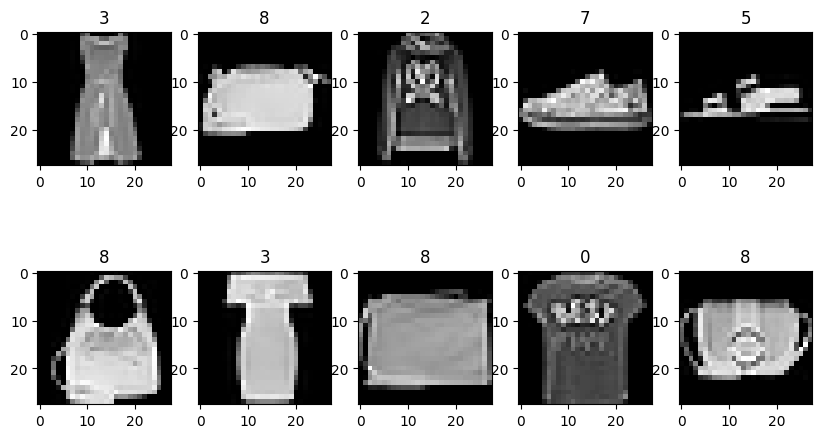

In [4]:
# view sample images from the dataset
plt.figure(figsize=(10, 15))
for i in range(10):
    plt.subplot(5, 5, i + 1)
    # squeeze removes any dimensions of size 1
    plt.imshow(train_dataset[i][0].squeeze(), cmap='gray')
    plt.title(train_dataset[i][1])
plt.show()

In [66]:
# implement the netowrk architecture
class LeNet5FeatureExtractor(nn.Module):
    def __init__(self):
        # builing up the learnable feature extractors
        super(LeNet5FeatureExtractor, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1, padding=2) # 32x32 -> 28x28
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2) # 28x28 -> 14x14

        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1, padding=2) # 14x14 -> 10x10
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2) # 10x10 -> 5x5
        self.conv3 = nn.Conv2d(in_channels=16, out_channels=84, kernel_size=4, stride=1, padding=0) # 5x5 -> 2x2
        self.pool3 = nn.AvgPool2d(kernel_size=2, stride=2) # 2x2 -> 1x1
        self.conv4 = nn.Conv2d(in_channels=84, out_channels=96, kernel_size=2, stride=1, padding=2) # 1x1 -> 2x2
        self.pool4 = nn.AvgPool2d(kernel_size=2, stride=2) # 2x2 -> 1x1
        self.conv5 = nn.Conv2d(in_channels=96, out_channels=120, kernel_size=2, stride=1, padding=0) # 1x1 -> 1x1

    def forward(self, x):
        x = F.tanh(self.conv1(x))
        x = self.pool1(x)
        x = F.tanh(self.conv2(x))
        x = self.pool2(x)
        x = F.tanh(self.conv3(x))
        x = self.pool3(x)
        x = F.tanh(self.conv4(x))
        x = self.pool4(x)
        x = F.tanh(self.conv5(x))

        return x
    
class LeNet5Classifier(nn.Module):
    def __init__(self, num_classes):
        super(LeNet5Classifier, self).__init__()
         # building the classifier
        self.fc1 = nn.Linear(in_features=120, out_features=84)
        self.fc2 = nn.Linear(in_features=84, out_features=num_classes)

    def forward(self, x):
        # apply the classification head
        x = F.tanh(self.fc1(x))
        x = self.fc2(x)
        return x

class LeNet5(nn.Module):
    def __init__(self, num_classes=10):
        super(LeNet5, self).__init__()
        # define the feature extractor
        self.feature_extractor = LeNet5FeatureExtractor()
        # define the classifier
        self.classifier = LeNet5Classifier(num_classes)

    def forward(self, x):
        # extract the features
        x = self.feature_extractor(x)
        # flatten the output of the last conv layer
        x = x.view(x.size(0), -1)
        # apply the classifier
        x = self.classifier(x)
        return x
        

# instantiate the model
model = LeNet5()

# print the model architecture
print(model)

LeNet5(
  (feature_extractor): LeNet5FeatureExtractor(
    (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (pool1): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (pool2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (conv3): Conv2d(16, 84, kernel_size=(4, 4), stride=(1, 1))
    (pool3): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (conv4): Conv2d(84, 96, kernel_size=(2, 2), stride=(1, 1), padding=(2, 2))
    (pool4): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (conv5): Conv2d(96, 120, kernel_size=(2, 2), stride=(1, 1))
  )
  (classifier): LeNet5Classifier(
    (fc1): Linear(in_features=120, out_features=84, bias=True)
    (fc2): Linear(in_features=84, out_features=10, bias=True)
  )
)


In [67]:
# define the device and move the model to the device
device = torch.device("cuda")

In [68]:
model.to(device)

LeNet5(
  (feature_extractor): LeNet5FeatureExtractor(
    (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (pool1): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (pool2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (conv3): Conv2d(16, 84, kernel_size=(4, 4), stride=(1, 1))
    (pool3): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (conv4): Conv2d(84, 96, kernel_size=(2, 2), stride=(1, 1), padding=(2, 2))
    (pool4): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (conv5): Conv2d(96, 120, kernel_size=(2, 2), stride=(1, 1))
  )
  (classifier): LeNet5Classifier(
    (fc1): Linear(in_features=120, out_features=84, bias=True)
    (fc2): Linear(in_features=84, out_features=10, bias=True)
  )
)

In [69]:
# training the model

# to train the model we need to define the objective and the optimizer

# define the objective
criterion = nn.CrossEntropyLoss()

# define the optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [70]:
import time

In [74]:
for epoch in range(10):
    epoch_start_time = time.time()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        if batch_idx % 100 == 0:
            print(f"Epoch {epoch} | Batch {batch_idx} | Loss {loss.item():.4f}")
    # evaluate the model
    with torch.no_grad():
        val_loss = 0
        correct = 0
        total = 0
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            val_loss += loss.item()
            _, predicted = torch.max(output.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
        print(f"Epoch {epoch} | Val Loss {val_loss / len(val_loader):.4f} | Val Accuracy {100 * correct / total:.2f}% Avg val loss {val_loss / len(val_loader):.4f}")
    print(f"Epoch {epoch} | Time {time.time() - epoch_start_time:.2f}s")


Epoch 0 | Batch 0 | Loss 0.0664
Epoch 0 | Batch 100 | Loss 0.0944
Epoch 0 | Batch 200 | Loss 0.1195
Epoch 0 | Batch 300 | Loss 0.0949
Epoch 0 | Batch 400 | Loss 0.0792
Epoch 0 | Batch 500 | Loss 0.2072
Epoch 0 | Batch 600 | Loss 0.1567
Epoch 0 | Batch 700 | Loss 0.2541
Epoch 0 | Val Loss 0.3550 | Val Accuracy 89.09% Avg val loss 0.3550
Epoch 0 | Time 4.87s
Epoch 1 | Batch 0 | Loss 0.1035
Epoch 1 | Batch 100 | Loss 0.0990
Epoch 1 | Batch 200 | Loss 0.0976
Epoch 1 | Batch 300 | Loss 0.0694
Epoch 1 | Batch 400 | Loss 0.0479
Epoch 1 | Batch 500 | Loss 0.1006
Epoch 1 | Batch 600 | Loss 0.1202
Epoch 1 | Batch 700 | Loss 0.1625
Epoch 1 | Val Loss 0.3498 | Val Accuracy 89.79% Avg val loss 0.3498
Epoch 1 | Time 4.94s
Epoch 2 | Batch 0 | Loss 0.1043
Epoch 2 | Batch 100 | Loss 0.1289
Epoch 2 | Batch 200 | Loss 0.1414
Epoch 2 | Batch 300 | Loss 0.1319
Epoch 2 | Batch 400 | Loss 0.1594
Epoch 2 | Batch 500 | Loss 0.0711
Epoch 2 | Batch 600 | Loss 0.1004
Epoch 2 | Batch 700 | Loss 0.0888
Epoch 2 | Va

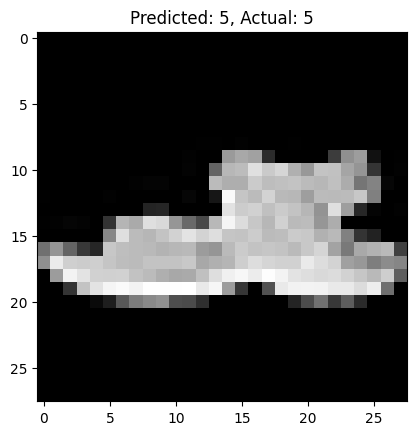

Test Accuracy: 88.56%


In [78]:
### perform tests on the model
correct = 0
total = 0

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        _, predicted = torch.max(output.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()
        if torch.rand(1) < 0.2:
            plt.imshow(data[0].cpu().squeeze(), cmap='gray')
            plt.title(f"Predicted: {predicted[0].item()}, Actual: {target[0].item()}")
            plt.show()

print(f"Test Accuracy: {100 * correct / total:.2f}%")